In [1]:
import torch 
import torch.nn as nn 
from torch.nn import functional as F 
import sys 
sys.path.append('..')
from train import TrainModel


In [2]:
model = TrainModel.load_from_checkpoint('/home/kathy/projects/project_guo/test/logs/logger_train2/version_7/checkpoints/epoch=499-step=30500.ckpt')

In [3]:
model.device

device(type='cuda', index=9)

In [4]:
# from custom_dataset.data_loader import get_dataloader
from custom_dataset.dataset import get_dataloader

In [5]:
train_loader, val_loader = get_dataloader()

In [6]:
img, mask = next(iter(val_loader))
img.shape, mask.shape 

(torch.Size([8, 4, 1, 128, 128]), torch.Size([8, 4, 1, 128, 128]))

In [7]:
img , mask = img.to(model.device), mask.to(model.device)

In [8]:
(img - mask).sum() / torch.prod(torch.tensor(img.shape))

tensor(-0.7466, device='cuda:9')

In [9]:
torch.unique(mask)

tensor([0, 1, 2, 3, 4], device='cuda:9')

In [10]:
img 

tensor([[[[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           ...,
           [-1.0000, -0.9922, -1.0000,  ..., -0.5765, -0.6392, -0.6235],
           [-1.0000, -0.9922, -0.9922,  ..., -0.6157, -0.7020, -0.6314],
           [-0.9922, -0.9843, -0.9843,  ..., -0.6471, -0.7020, -0.6314]]],


         [[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           ...,
           [-0.5922, -0.5922, -0.5686,  ...,  0.3255, -0.2314, -0.3490],
           [-0.5765, -0.6314, -0.6235,  ...,  0.6392,  0.1294, -0.3020],
           [-0.6078, -0.6392, -0.5843,  ...,  0.7020,  0.4667, -0.1059]]],


         [[[-0.6471, -0.5765, -0.4824,  ...,  0.5922,  0.6235,  0.1765],
           

In [11]:
img.shape 

torch.Size([8, 4, 1, 128, 128])

In [12]:
img = img.view(8 * 4, 1, 128, 128)
# img = img / 255
pred = model(img)

/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/torch/nn/functional.py:3722: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


In [13]:
pred.shape 

torch.Size([32, 5, 128, 128])

In [14]:
mask = mask.reshape(8 * 4, 128, 128)

In [15]:
mask.shape 

torch.Size([32, 128, 128])

In [25]:
ce_loss = nn.CrossEntropyLoss(label_smoothing=0)
ce_loss(pred, mask)

tensor(0.0052, device='cuda:9', grad_fn=<NllLoss2DBackward0>)

In [17]:
torch.unique(mask)

tensor([0, 1, 2, 3, 4], device='cuda:9')

In [18]:
pred.shape , mask.shape 

(torch.Size([32, 5, 128, 128]), torch.Size([32, 128, 128]))

In [19]:
plot_pred = pred.argmax(dim = 1)

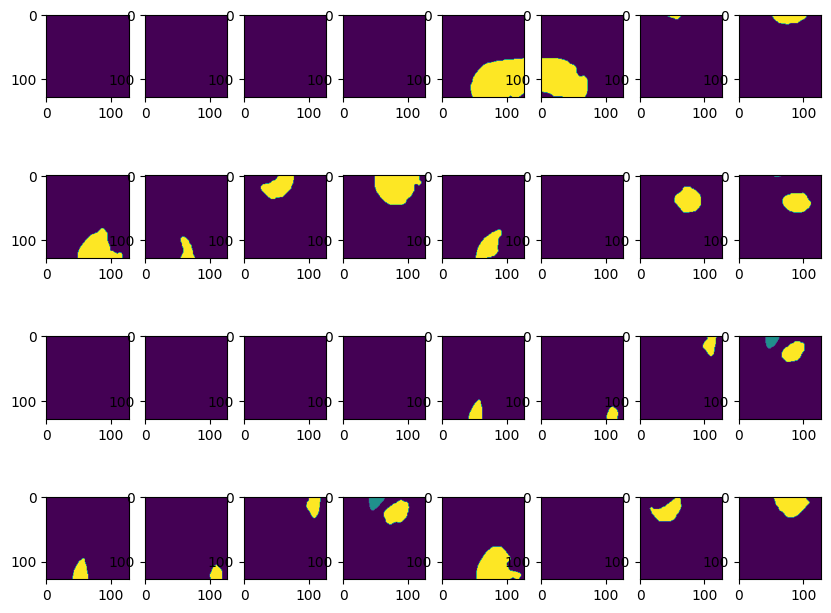

In [20]:
from matplotlib import pyplot as plt 
fig, axes = plt.subplots(4, 8)
fig.set_size_inches(10, 8)
for i in range(32):
    axes.flatten()[i].imshow(plot_pred[i].cpu().detach().numpy())

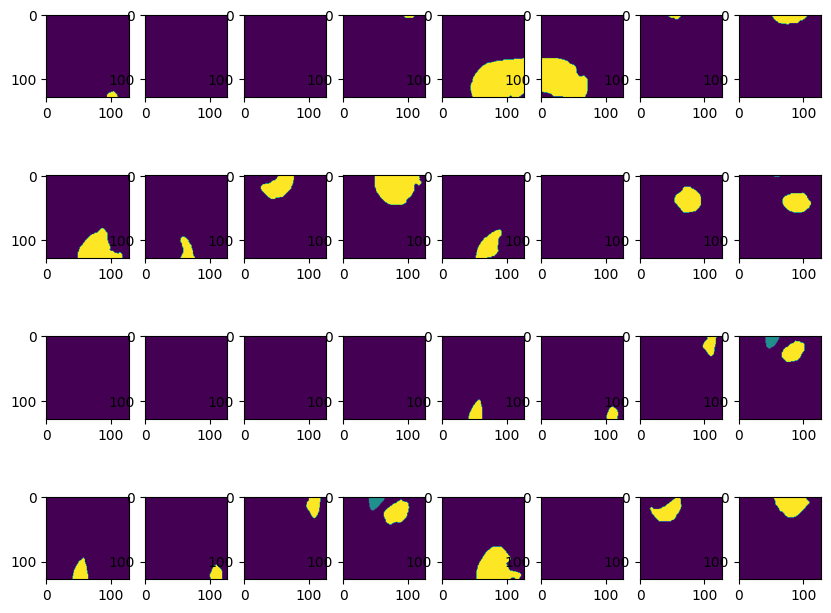

In [21]:
from matplotlib import pyplot as plt 
fig, axes = plt.subplots(4, 8)
fig.set_size_inches(10, 8)
for i in range(32):
    axes.flatten()[i].imshow(mask[i].cpu().detach().numpy())

In [22]:
(plot_pred == mask).sum() / (32* 128* 128)

tensor(0.9994, device='cuda:9')

In [23]:
mask[mask != 0]

tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:9')

In [24]:
(plot_pred[mask!=0] ==  mask[mask!= 0]).sum() /  (mask != 0 ).sum()

tensor(0.9918, device='cuda:9')

In [36]:
plot_pred.shape 

torch.Size([32, 128, 128])

In [37]:
import numpy as np 
def substract(x,y):
    """
    求2个2维0-1矩阵相减，用于求FP,FN
    :return:value
    """
    z=x-y
    z=np.maximum(z,0)
    return np.sum(z)
def sen_ppv(mask_pred:torch.tensor,mask_true:torch.tensor,epsion=1e-4):
    #仅适用于二维
    mp,mt=mask_pred.to('cpu').numpy(),mask_true.to('cpu').numpy()
    mp=mp[:, 1:, ...]
    mt=mt[:, 1:, ...]
    dice_res,sen_res,ppv_res=0,0,0
    bs=mp.shape[0]
    for i in range(bs):
        mtt=np.squeeze(mt[i])
        mpp=np.squeeze(mp[i])
        TP=np.sum(mtt*mpp)
        FP=substract(mpp,mtt)
        FN=substract(mtt,mpp)
        dice_res+=2*TP/(2*TP+FP+FN+epsion)
        sen_res+=TP/(TP+FN+epsion)
        ppv_res+=TP/(TP+FP+epsion)
    return dice_res/bs,sen_res/bs,ppv_res/bs

In [38]:
pred.shape 

torch.Size([32, 5, 128, 128])

In [39]:
sen_ppv(pred.detach().softmax(dim = 1),  nn.functional.one_hot(mask, 5).permute(0, 3, 1, 2) )

(0.6891011851339087, 0.6881785021799747, 0.6987309792934835)

In [31]:
from scipy.spatial import distance

In [35]:
distance.dice(pred.detach().cpu().numpy().flatten(), nn.functional.one_hot(mask, 5).permute(0, 3, 1, 2).cpu().numpy().flatten())

-0.8384450525536776